# Structure

- Problem Definition
- EDA
- Preprocessing
- Metrics
- Modelling

# Problem Definition

A diabetes diagnosis classification problem.
- There are 2 distinct scenarios: binary and ternary classification.
- Same input features for both scenarios, different targe feature.

Scenarios:
- Binary: no-diabetes (0), and diabetes(1).
- Ternary: no-diabetes (0), pre-diabetes(1), and diabetes(2).

## Import Libraries and dataset

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import kagglehub

Load Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
# List files in directory
print(os.listdir(path))

['diabetes_012_health_indicators_BRFSS2015.csv', 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv']


Datasets

To use:
- binary classification: diabetes_binary_health_indicators_BRFSS2015.csv
- ternary classification: diabetes_012_health_indicators_BRFSS2015.csv

NOT to use:
- diabetes_binary_5050split_health_indicators_BRFSS2015.csv

In [ ]:
# Create dataframes
file_path_binary = os.path.join(path, 'diabetes_binary_health_indicators_BRFSS2015.csv')
df_binary = pd.read_csv(file_path_binary)

file_path_ternary = os.path.join(path, 'diabetes_012_health_indicators_BRFSS2015.csv')
df_ternary = pd.read_csv(file_path_ternary)

In [ ]:
target_columns = ["Diabetes_012", "Diabetes_binary"]
target_binary = 'Diabetes_binary'
target_ternary = 'Diabetes_012'

In [ ]:
# Check if input features are the same for both datasets:
unique_columns = df_ternary.columns.symmetric_difference(df_binary.columns)
print("Column names not shared by both:", unique_columns.tolist())
common_cols = df_ternary.columns.intersection(df_binary.columns)
diff_content_cols = [col for col in common_cols if not df_ternary[col].equals(df_binary[col])]
print("Columns with same name but different content:", diff_content_cols)

Column names not shared by both: ['Diabetes_012', 'Diabetes_binary']
Columns with same name but different content: []


Only change is the Target feature:
- Doing EDA will be done combining both target features with input features.

Observations:
- Datasampling still needs to be done different in each scenario, according to target class distribution.

# EDA

Exploratory Data Analysis

Combine all features:

In [ ]:
df_all = pd.concat([df_ternary['Diabetes_012'], df_binary], axis=1)
print("Shape:", df_all.shape)
pd.set_option('display.max_columns', None)
display(df_all.head())

Shape: (229781, 23)


,Diabetes_012,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Feature Exploration


In [ ]:
# Check Feature data types
feature_types = df_all.dtypes.to_dict()
categorized_features = {}

for feature, data_type in feature_types.items():
    data_type_str = str(data_type)
    if data_type_str not in categorized_features:
        categorized_features[data_type_str] = []
    categorized_features[data_type_str].append(feature)

print("Data types:")
for data_type, features in categorized_features.items():
    print(f"{data_type}: {', '.join(features)}")

Data types:
float64: Diabetes_012, Diabetes_binary, HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income


All features are float type.

In [ ]:
# Identify feature types: binary and numeric
all_features_names = df_all.columns.to_list()
#all_features_names.remove(target_columns)
all_features_names = [feature for feature in all_features_names if feature not in target_columns]

# Input Features only:
binary_feature_list = [col for col in all_features_names if df_all[col].nunique() == 2]
continuous_feature_list = [col for col in all_features_names if col not in binary_feature_list]

print("binary features: ",binary_feature_list)
print("continuous features: ",continuous_feature_list)

binary features:  ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
continuous features:  ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


There are:
- binary features
- continuous features (includes numeric categorical ordinal features).

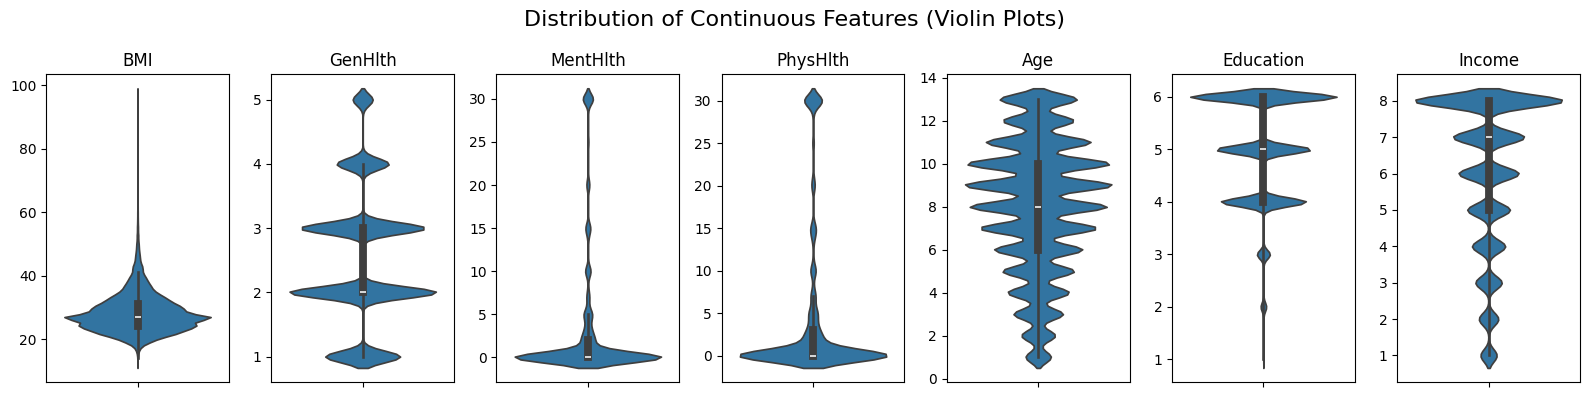

In [ ]:
# Violin
def plot_violin(df):
  fig, axes = plt.subplots(1, len(continuous_feature_list), figsize=(16, 4))
  fig.suptitle('Distribution of Continuous Features (Violin Plots)', fontsize=16)
  for i, col in enumerate(continuous_feature_list):
      sns.violinplot(y=df[col], ax=axes[i])
      axes[i].set_title(f'{col}')
      axes[i].set_ylabel("")
  plt.tight_layout()
  plt.show()

plot_violin(df_all)

Analyze features:

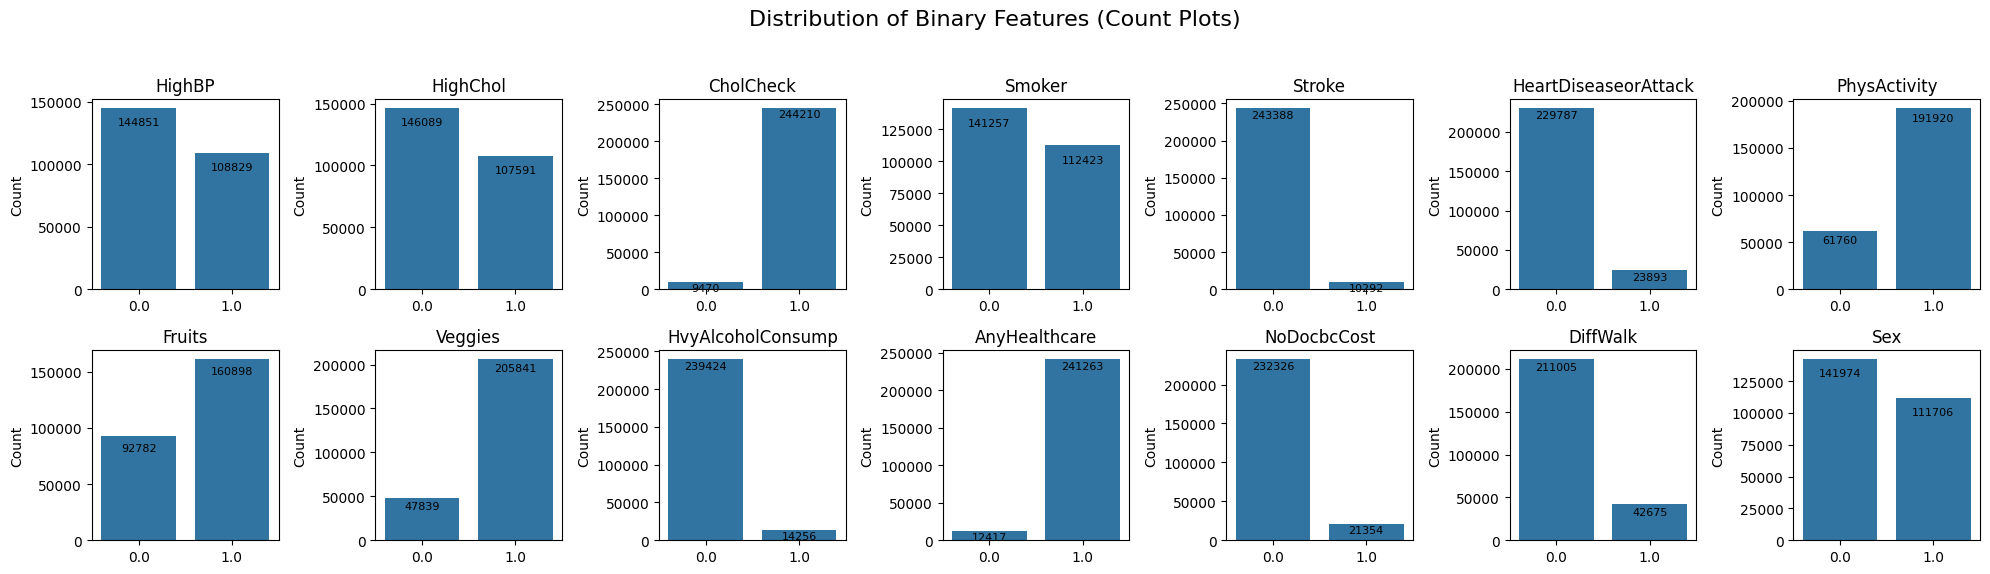

In [ ]:
def plot_binary_features(df):
  rows = 2
  cols = (len(binary_feature_list) + 1) // rows
  fig, axes = plt.subplots(rows, cols, figsize=(20, 6))
  fig.suptitle('Distribution of Binary Features (Count Plots)', fontsize=16)
  for i, col in enumerate(binary_feature_list):
      ax = axes[i // cols, i % cols]
      sns.countplot(x=df_binary[col], ax=ax)
      ax.set_title(col)
      ax.set_xlabel("")
      ax.set_ylabel("Count")
      # Place bar counts
      for p in ax.patches:
        count = int(p.get_height())
        x = p.get_x() + p.get_width() / 2  # Center text
        y = p.get_height() - 15000       # Position text
        ax.text(x, y, count, ha='center', va='bottom', fontsize=8, color='black')  # Add count
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

plot_binary_features(df_all)

In [ ]:
# Target distribution

## Pie Chart Methods

### Plot a subplot
def _plot_single_class_distribution(y, title, class_names=None):
    unique_classes, class_counts = np.unique(y, return_counts=True)
    # Create labels using class_names if provided
    if class_names is not None:
        labels = [f'{class_names[cls]}: {count:_} ({count/len(y)*100:.1f}%)'
                 for cls, count in zip(unique_classes, class_counts)]
    else:
        labels = [f'{cls}: {count:_} ({count/len(y)*100:.1f}%)'
                 for cls, count in zip(unique_classes, class_counts)]

    plt.pie(class_counts, labels=labels, autopct=None,
            colors=sns.color_palette('viridis', len(unique_classes)),
            startangle=90, wedgeprops={'edgecolor': 'black'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('equal')


### Plot just one plot
def plot_class_distribution_individual(y,title, class_names):
  plt.figure(figsize=(10, 5))
  _plot_single_class_distribution(y,title, class_names)
  plt.tight_layout()
  plt.show()

### Side by side plot
def plot_class_distribution_side_by_side(y1, y2, title1, title2, class_names1=None, class_names2=None):
  plt.figure(figsize=(10, 5))
  # First subplot
  plt.subplot(1, 2, 1)
  _plot_single_class_distribution(y1,title1, class_names1)
  # Second subplot
  plt.subplot(1, 2, 2)
  _plot_single_class_distribution(y2,title2, class_names2)
  plt.tight_layout()
  plt.show()

In [ ]:
ternary_class_map = {0: 'No diabetes', 1: 'prediabetic', 2: 'diabetic'}
binary_class_map = {0: 'No diabetes', 1: 'diabetic'}


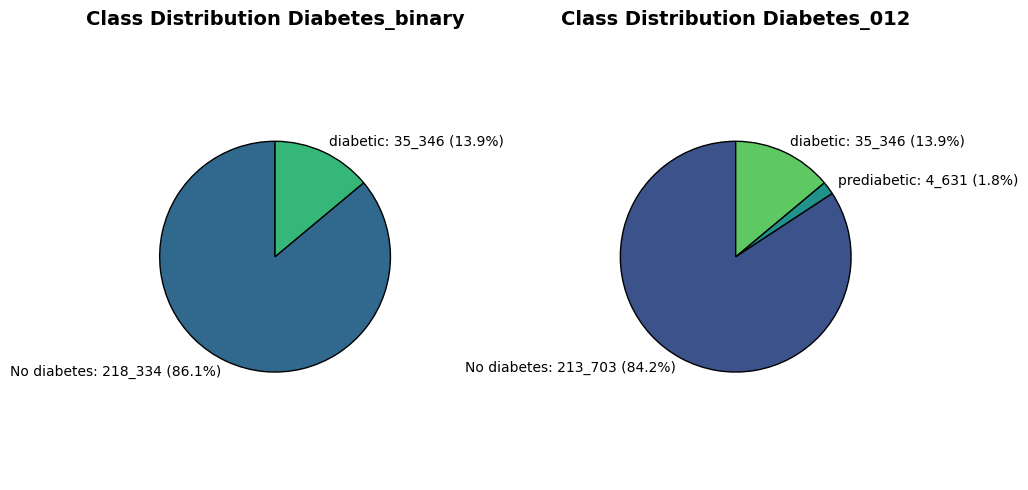

In [ ]:
plot_class_distribution_side_by_side(
    df_all[target_binary], df_all[target_ternary],
    f'Class Distribution {target_binary}',
    f'Class Distribution {target_ternary}',
    binary_class_map, ternary_class_map)

Data imbalance will be dealt with in the preprocessing section.

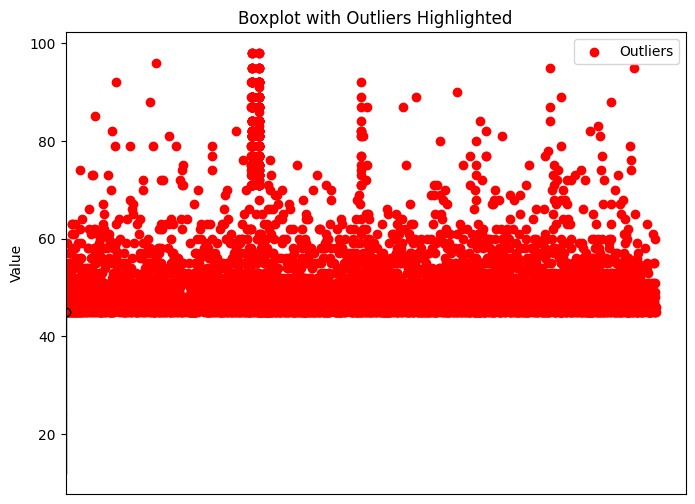

In [ ]:
df = df_all
# Calculate Q1, Q3, and IQR
out_feat_name = "BMI"

Q1 = df[out_feat_name].quantile(0.25)
Q3 = df[out_feat_name].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = df[(df[out_feat_name] < (Q1 - 1.5 * IQR)) | (df[out_feat_name] > (Q3 + 1.5 * IQR))]

# Plot boxplot with outliers highlighted
plt.figure(figsize=(8, 6))
plt.boxplot(df[out_feat_name], patch_artist=True, boxprops=dict(facecolor='cyan'))

# Highlight outliers in red
plt.scatter(
    np.where(df[out_feat_name].isin(outliers[out_feat_name]))[0] + 1,   # x-coordinates
    outliers[out_feat_name],                                            # y-coordinates
    color='red', label='Outliers'
)

plt.title('Boxplot with Outliers Highlighted')
plt.ylabel('Value')
plt.legend()
plt.show()

As seen here (in this small example only using the BMI variable), there are too many outliers for us to remove from the dataset. 

## Correlation Analysis

Input feature correlation

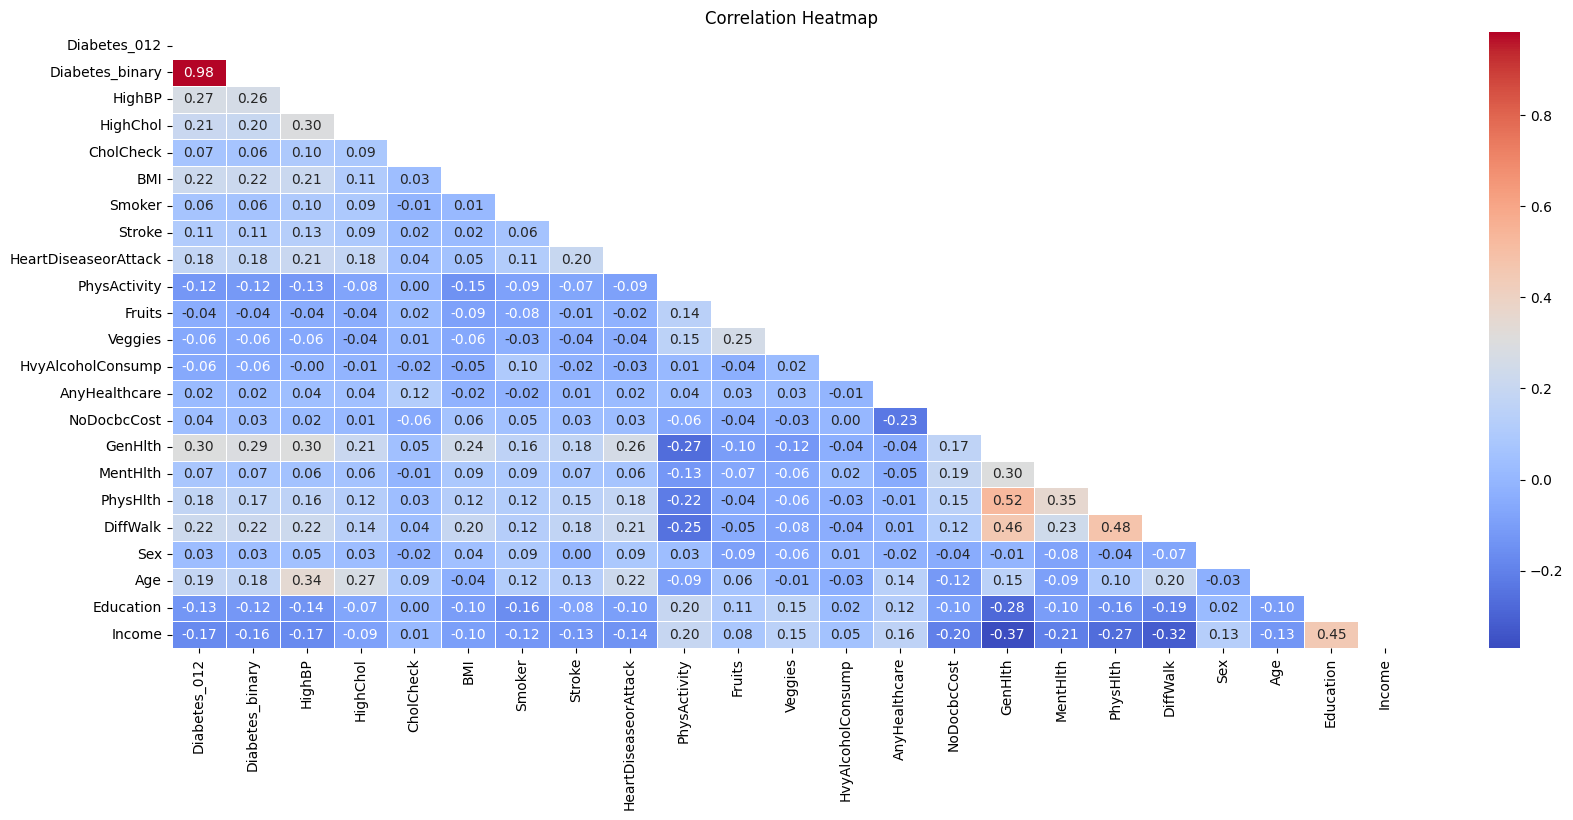

In [ ]:
correlation_matrix = df_all.corr(method='pearson')
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

-> There's not that much correlation between input features. No need for similar features removal.

Feature Correlation with Target (binary and ternary)

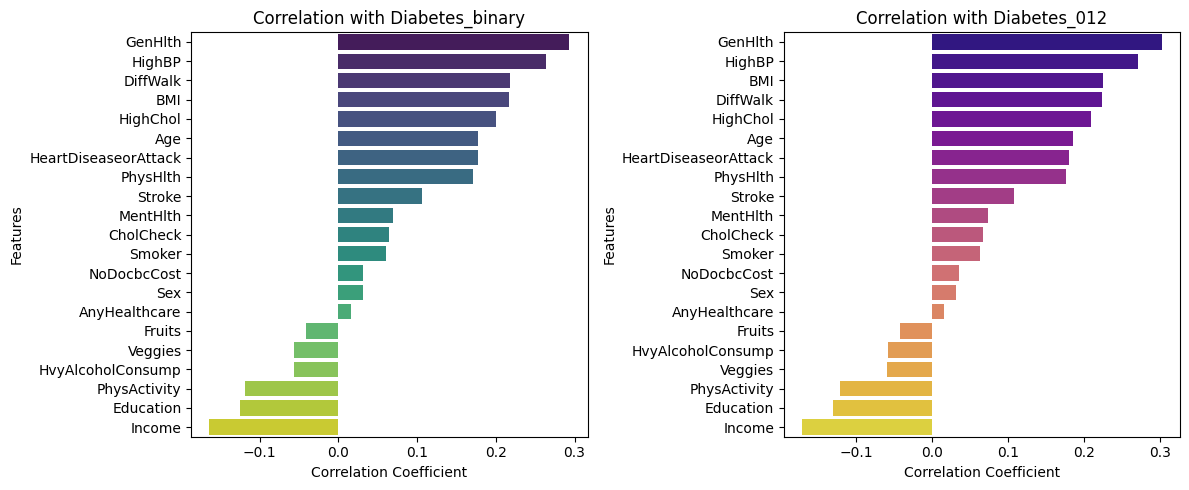

In [ ]:
target_binary = 'Diabetes_binary'
target_ternary = 'Diabetes_012'
correlations_binary = df_all.corr(numeric_only=True)[target_binary].sort_values(ascending=False).drop(target_columns)
correlations_ternary = df_all.corr(numeric_only=True)[target_ternary].sort_values(ascending=False).drop(target_columns)

# Create Side-by-Side Horizontal Bar Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot for df_binary
sns.barplot(y=correlations_binary.index, x=correlations_binary.values, palette='viridis', ax=axes[0], hue=correlations_binary.index, legend=False)
axes[0].set_title(f'Correlation with {target_binary}')
axes[0].set_ylabel('Features')
axes[0].set_xlabel('Correlation Coefficient')

# Plot for df_ternary
sns.barplot(y=correlations_ternary.index, x=correlations_ternary.values, palette='plasma', ax=axes[1], hue=correlations_ternary.index, legend=False)
axes[1].set_title(f'Correlation with {target_ternary}')
axes[1].set_ylabel('Features')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

-> Correlation between features and each target is very similar, as expected.

Correlation between each target ternary class and input features

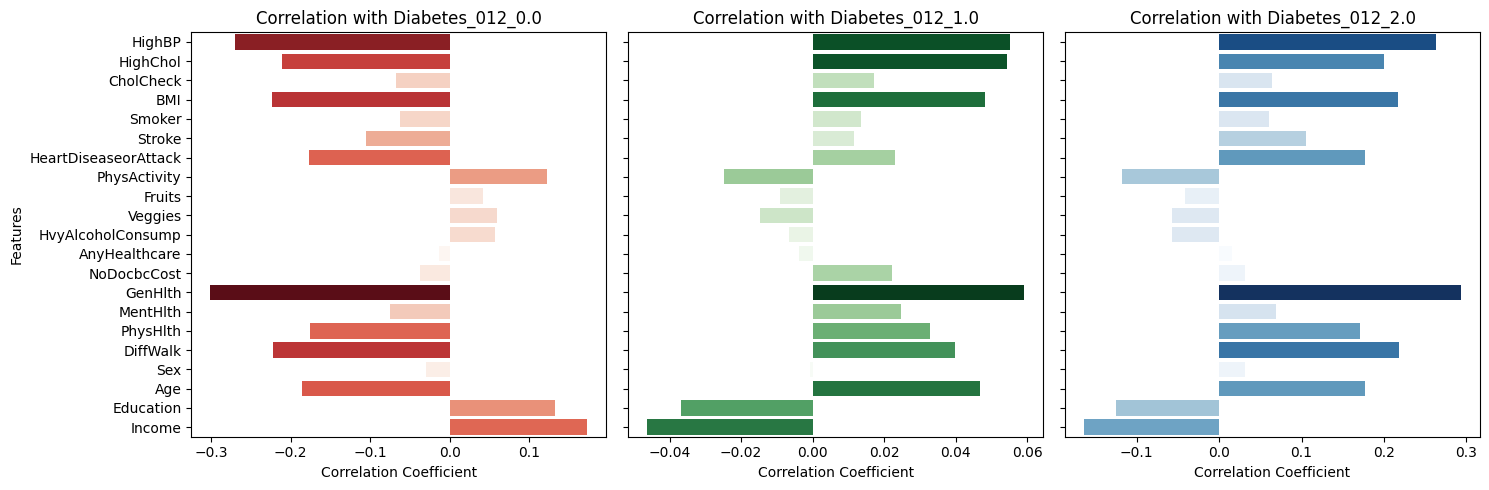

In [ ]:
# One-hot encode the ternary target
one_hot_target = pd.get_dummies(df_ternary['Diabetes_012'], prefix='Diabetes_012')

# Calculate correlation of features with each one-hot encoded class
correlations_per_class = {}
for col in one_hot_target.columns:
    correlations_per_class[col] = df_ternary.drop(columns=['Diabetes_012']).corrwith(one_hot_target[col])

# Convert to DataFrame
correlations_per_class_df = pd.DataFrame(correlations_per_class)

# Plotting side-by-side horizontal bar plots for each class
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

colors = ['Reds', 'Greens', 'Blues']
for i, col in enumerate(correlations_per_class_df.columns):
    # Map color intensity to correlation strength
    sns.barplot(y=correlations_per_class_df.index, x=correlations_per_class_df[col],
                hue= abs(correlations_per_class_df[col]), palette=colors[i],
                legend=False, ax=axes[i])
    axes[i].set_title(f'Correlation with {col}')
    axes[i].set_xlabel('Correlation Coefficient')
    [axes[i].set_ylabel('Features') if i == 0 else axes[i].set_ylabel('')]
plt.tight_layout()
plt.show()

- Prediabetes (1) is similar to diabetes (2) in terms of correlations.
- No diabetes (0) is the complete opposite of the other classes.

Correlation between one-hot-encoded features and ternary target feature

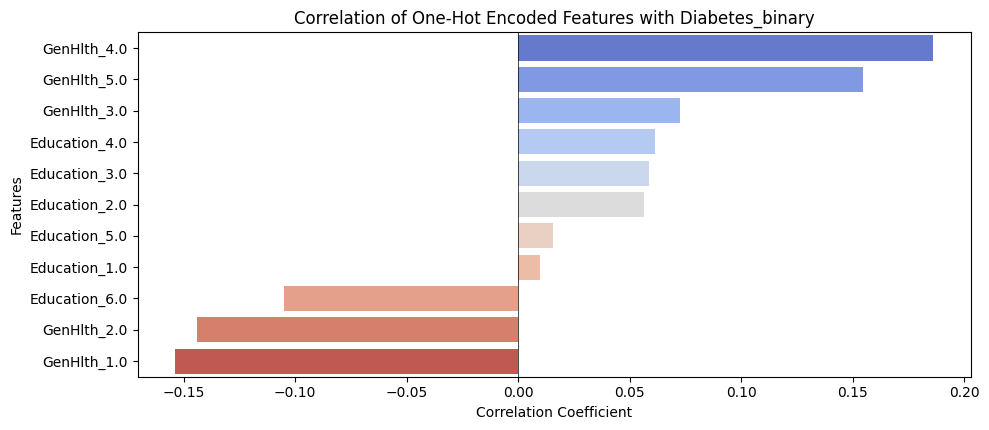

In [ ]:
target_ternary = 'Diabetes_012'
target_binary = 'Diabetes_binary'
target = target_binary

# Select less features
cols_to_encode = [col for col in continuous_feature_list if len(df_all[col].unique()) <= 6]
#cols_to_encode.remove(target_ternary)

# One-hot encoding
one_hot_encoded = pd.get_dummies(df_all[cols_to_encode], columns=cols_to_encode)

# Add target column
one_hot_encoded[target] = df_all[target]

# Calculate correlation between features and target and create DataFrame
corr_df = one_hot_encoded.corr()[target].drop(target).to_frame(name='Correlation with Target')

# Sort
corr_df_sorted = corr_df.sort_values(by='Correlation with Target', ascending=False)

# Create the horizontal bar plot
plt.figure(figsize=(10, len(corr_df_sorted) * 0.4))
sns.barplot(
    x='Correlation with Target',
    y=corr_df_sorted.index,
    hue=corr_df_sorted.index,
    data=corr_df_sorted,
    palette='coolwarm',
    legend=False
)
plt.title('Correlation of One-Hot Encoded Features with Diabetes_binary')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(0, color='black', linewidth=0.5) # Add a vertical line at zero for reference
plt.tight_layout()
plt.show()

-> GenHlth's classes have the highest correlation and are still very low (less than 20%).

-> The correlation between GenHlth and target feature is higher than the individual classes's dummy variables with target.

-> No one-hot-encoding will be done in the preprocessing pipeline.

## PCA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
#from umap import UMAP

target_ternary = 'Diabetes_012'

def plot_pca(df, target):
  # Feature scale
  X = StandardScaler().fit_transform(df.drop(columns=[target]))
  # Do PCA
  pca_df = pd.DataFrame(PCA(n_components=2).fit_transform(X), columns=['PC1', 'PC2'])
  pca_df[target] = df[target].astype(int)
  # Class order of plot placement
  class_counts_desc = pca_df[target].value_counts().sort_values(ascending=False).index.tolist()
  # Plot
  fig = px.scatter( pca_df,x='PC1', y='PC2', color=target,
                  category_orders={target: class_counts_desc},  # Plot in descending order of count
                  title='PCA', labels={'PC1': 'PC1', 'PC2': 'PC2'},
                  color_discrete_sequence=px.colors.qualitative.Set1, opacity=0.6)
  fig.show()

plot_pca(df_ternary, target_ternary)

Classes don't separate very well.

There's some semblance of separation between classes 0 and 2.

# Preprocessing


## Deciding Preprocessing Order

### Step Order:
- Clean Data
- Split into scenarios (binary and ternary)
- Data Splitting (train, val, test)
- Feature Engineering
- Feature Selection
- Data Sampling


### Ordering reason:
- Clean Data
  - Remove duplicates
  - (No outlier, No Missing Data)
- Split Data into Scenarios
  - Each problem (binary/ternary) needs separate splits to preserve their unique class distributions.
- Data Splitting
  - train_test_split -> (train, val, test)
  - Data Splitting is done before Feature Engineering to isolate evaluation set and prevent data leakage.
  - Avoid Data leakage: Never use the test set to modify, create or select feature. This preserves evaluation integrity.
- Feature Engineering
  - After splitting, fit on train only.
- Feature Selection
  - After engineering, fit on train only.
- Data Sampling:
  - Data Sampling is done after Feature Engineering.
  - On train set only. Must not affect the test set.

## Clean Data

## Deduplication

In [ ]:
def find_total_duplicates(df):
    # Find all duplicated rows
    duplicates = df[df.duplicated(keep=False)]
    # Total number of duplicated rows
    total_duplicates = len(duplicates)
    return total_duplicates
print(f"Total number of duplicate rows: {find_total_duplicates(df_all)}")

Total number of duplicate rows: 35086


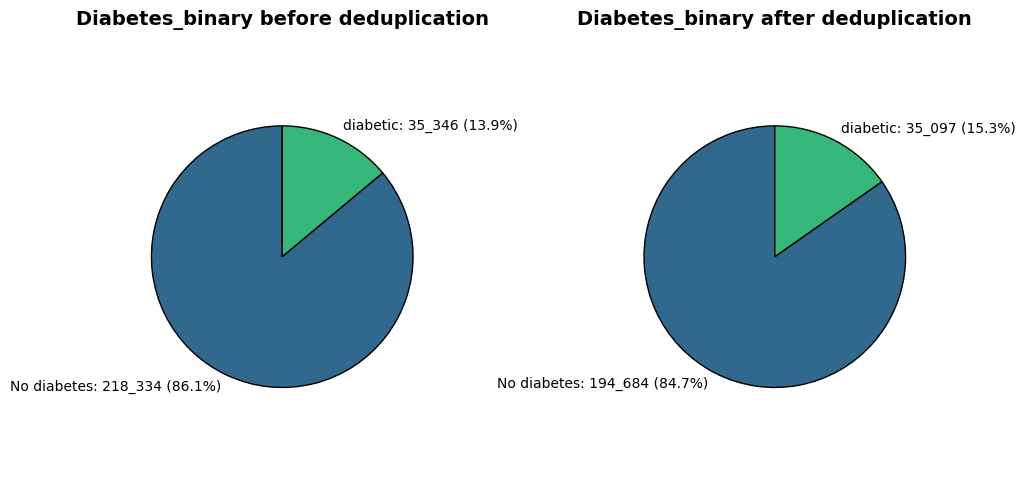

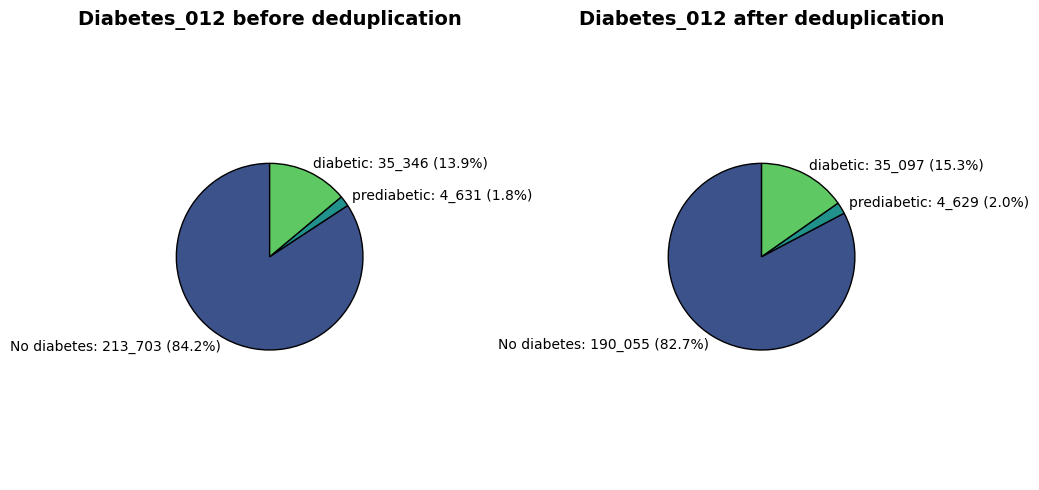

In [ ]:
# Remove duplicates
def remove_duplicates_keep_one(df):
    return df.drop_duplicates()

# Reset
df_all = pd.concat([df_ternary['Diabetes_012'], df_binary], axis=1)

# Before
before_df = df_all.copy()
# After - deduplication
df_all = remove_duplicates_keep_one(df_all)

# Plot
## binary
plot_class_distribution_side_by_side(
    before_df[target_binary], df_all[target_binary],
    f'{target_binary} before deduplication', f'{target_binary} after deduplication',
    binary_class_map, binary_class_map)
## ternary
plot_class_distribution_side_by_side(
    before_df[target_ternary], df_all[target_ternary],
    f'{target_ternary} before deduplication', f'{target_ternary} after deduplication',
    ternary_class_map, ternary_class_map)

Deduplication didn't affect minority class too much!

## Missing Values

In [ ]:
missing_values_percentage = df_all.isnull().mean() * 100
features_with_missing = missing_values_percentage[missing_values_percentage > 0]

if not features_with_missing.empty:
    print("Percentage of Missing Values by Feature:")
    [print(f"{feature}: {percentage:.2f}%") for feature, percentage in features_with_missing.items()]
else:
    print("No features with null values found in the DataFrame.")

No features with null values found in the DataFrame.


No missing values, no Imputation Methods needed.

## Split into scenarios

Data spliting must be done differently, for each scenario (binary and ternary), to preserve target class balance.
- (Here we don't use the original datasets because we already did dedupication on all features combined).

In [ ]:
# binary
df_binary = df_all.drop(columns=[target_ternary])

# ternary
df_ternary = df_all.drop(columns=[target_binary])

## Data Splitting

Split data into training set, validation set, and testing set.
- Since dataset is large, a smaller validation/test set will be chosen.
- It still allows for a reliable evaluation while having more data for models to generalize better.
- Split:
    - Train: 80%
    - Validation: 10%
    - Test: 10%
- Use of stratify: Preserve the same data (im)balance on all sets (same proportions of classes).

In [ ]:
from sklearn.model_selection import train_test_split

def data_split(X,y):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=63, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=63, stratify=y_temp)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
# Binary classification split
X_train_bin, X_val_bin, X_test_bin, y_train_bin, y_val_bin, y_test_bin = data_split( df_binary.drop(target_binary, axis=1),   df_binary[target_binary])

# Ternary classification split
X_train_ter, X_val_ter, X_test_ter, y_train_ter, y_val_ter, y_test_ter = data_split( df_ternary.drop(target_ternary, axis=1),   df_ternary[target_ternary])

- From now on feature transformations will be fitted (then transformed) only to training sets.
- Then, using that fit, evaluation sets (validation and test sets) will be transformed.

Preprocessing will be done to all sets. Then save to a dictionary of sets.

## Feature Engineering

### Considered Techniques

**One Hot Encoding (OHE)**:
- A technique that converts categorical variables into a binary format.
- Creates new columns for each category, where 1 means the category is present and 0 means it is not.
- Encode "categorical variables" into binary [0,1] before scaling.

**Normalization**:
A feature scaling technique that tries to mitigate the impact of varying feature ranges, ensuring equall contribution to models' performance.
- MinMaxScaler: explicitly scale data to a specific range like [0,1].
- BoxCox: Aims to transform non-normally distributed data into a Gaussian-like distribution. Stabilizes variance across data range.

**Standardization**:
A feature scaling technique that converts data to a uniform format, typically for data to have mean of 0 and standard deviation of 1.
- StandardScale: Process known as z-score. Mean of 0, std of 1.
- Equation: $z= \frac{(x−u)}{s}$.
- Useful for feature scale sensitive algorithms (e.g. SVMs and KNN).
- If data follows a normal distribution, most values (99.7%) fall between [-3, 3] (3 standard deviations of the mean).

**Dimensionality reduction technique**:
- We considered using PCA to get higher correlated features, but chose not to. Why not add PCA features?
- I could select Principal Component (PC) features that explain 70% (CEV) of data. But PCA reduces interpretability.
- Adding PCA PC features, from the input features to the dataset, would be replicating data that already is in the dataset, potentially leading to bias, causing the model to learn patterns that are too specific to the training data and not generalize well.
- No PCA features will be added as input features to the datasets.

**Considerations**:
- Because intended models (SVMs and Neural Networks) are sensitive to the scale of input features, feature scaling (standardization) is needed.
- For Neural Networks, standardization is often preferred: aligns with the assumption of normally distributed inputs for activation functions and weight updates.
- For SVMs normalization can overemphasize outliers, potentially hiding important data structures.
- Tree-based models and are generally invariant to feature scaling. Random Forest does not require scaling (but will be done to streamline and use the same dataset).

**Choice of Order**:
- One Hot Encoding (OHE):  (Not Done!)
    - Scaling after OHE ensures dummy variables have mean 0 and variance 1, which can be beneficial for models like neural networks.
    - Doing OHE first avoids scaling raw categorical data, which is meaningless.
    - OHE won't be done because features are best done with other transformations - in the dataset there aren't nominal categorical features.

1) Box-Cox (normalization - Power transform):
    - Box-Cox transforms data to approximate normality,
    - Use Box-Cox to "numerical features" that are non-normal skewed distributions.
    - Can improve model performance for algorithms assuming normal distributions.
    - Box-Cox precedes scaling, because scaling assumes a certain distribution.
    - Box-Cox requires positive data: handle zero or negative values appropriately.
    - (Could have used Yeo-Johnson, also aims to make data more Gaussian-like and does not require data to be positive. But didn't.)
2) StandardScaler (standardization):
    - Apply scaling (e.g. StandardScaler, MinMaxScaler) after OHE and Box-Cox.
    - Scale "all features" to ensure uniformity across the dataset.
    - After normalization, do standardization (StandardScale) to all features.
- Dimensionality reduction (Not Done!)
    - Apply after scaling (PCA is feature scale sensitive) but before model training.
- Binning  (Not considered)

**Source**:
- [geeksforgeeks: standardscaler](https://www.geeksforgeeks.org/difference-between-standardscaler-and-normalizer-in-sklearn-preprocessing/)
- [sklearn StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).
- [geeksforgeeks: BoxCox](https://www.geeksforgeeks.org/box-cox-transformation-using-python/)
- [geeksforgeeks: OHE](https://www.geeksforgeeks.org/ml-one-hot-encoding/)


In [ ]:
# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler

## binary features
binary_transformer = Pipeline([ ('scaler', StandardScaler()) ])

## numerical features
numerical_transformer = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(1, 2))),
    # MinMaxScaler to make sure features only have positive values - boxcox only handles positive data (no return errors) .
    ('boxcox', PowerTransformer(method='box-cox', standardize=True)),# Box-Cox for normality
    # Standardize already does what StandardScaler would do. No need to add it.
    # remainder='passthrough'  # Don't forget this to include other columns
    # yeojohnson was a possible choice, that deals with negative and zero values.But was decided against.
    # ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=True))  # Yeo-Johnson transformation
])

# Combine pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, continuous_feature_list),
        ('bin', binary_transformer, binary_feature_list)
        ]
)

Data sampling can precede or follow feature selection

## Feature Selection


Feature selection seeks to identify and select the most relevant input features that contribute to predicting the target variable.

Helps reduce model complexity, improve performance, decrease training time, and mitigate overfitting by eliminating irrelevant or redundant features.

**Deciding which approach to take**:

- Keep All Features? Is an option, and with not too many features (21) it would be fine to leave all in.

- Despite low correlation with target feature for some, retaining all features can be a valid approach.

**Context**:
- **Non-Linear Relationships**: Low correlation doesn't necessarily mean a feature is irrelevant. Correlation measures linear associations, and machine learning models (especially non-linear ones like neural networks and Random Forests), can capture complex, non-linear patterns that aren’t reflected in correlation coefficients. A near-zero correlation feature might still contribute to predictive power.
- **Model Performance Over Assumptions**: Dropping features based solely on low correlation can be risky, especially without testing their impact on model performance.
- **Small Feature Set**: With only 21 features, computational cost is unlikely a significant issue. Keeping all features avoids the risk of prematurely discarding potentially useful information, especially since feature selection can sometimes reduce model performance.

- **Potential downsides to retaining all features**:
    - Noise and Overfitting: Features with very low relevance can introduce noise, potentially leading to overfitting, especially in smaller datasets where the model might learn spurious patterns.
    - Interpretability: A larger feature set can make it harder to interpret the model's decisions, which is often critical in healthcare applications like diabetes classification.

**Approach**:
- 1) Don't use feature selection based on correlation (filter methods): Chosen models are non-linear (MLP, RF, SVM can act as non-linear too), so use non-linear feature selection techniques.
- 2) Try using Random Forest and see what it gives back. RF is a non-linear model, which will be one of the models chosen to evaluate.

Feature selection based on correlation:
- But let's try to choose by correlation and see what happens:

In [ ]:
import pandas as pd
import numpy as np

def feature_selection_by_correlation(X, y, target_corr_threshold=0.1):
    data = X.copy()
    data['Target'] = y
    # Compute correlations
    corr_matrix = data.corr()
    # Compute correlations with target (filter by threshold)
    target_corr = corr_matrix['Target'].drop('Target')
    relevant_features = target_corr[abs(target_corr) > target_corr_threshold].index.tolist()
    # Features
    selected_features = [f for f in relevant_features]
    removed_features = [f for f in X.columns if f not in selected_features]

    return selected_features, removed_features

# Perform feature selection
## binary:
print("binary:")
corr_selected_features_bin, corr_removed_features_bin = feature_selection_by_correlation(X_train_bin, y_train_bin, target_corr_threshold=0.1)
print("Selected features:", corr_selected_features_bin)
print("Removed features:", corr_removed_features_bin)

## ternary:
print("ternary:")
corr_selected_features_ter, corr_removed_features_ter = feature_selection_by_correlation(X_train_ter, y_train_ter, target_corr_threshold=0.1)
print("Selected features:", corr_selected_features_ter)
print("Removed features:", corr_removed_features_ter)

binary:
Selected features: ['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']
Removed features: ['CholCheck', 'Smoker', 'Stroke', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'Sex']
ternary:
Selected features: ['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']
Removed features: ['CholCheck', 'Smoker', 'Stroke', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'Sex']


-> Almost half of the features were removed, even with a very low correlation threshold (10%). Not a good approach.

Feature selection using a random Forest:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd

def feature_selection_by_random_forest(X, y, threshold='median'):
    # threshold: Threshold for feature selection. Can be 'median' or float value.

    # Fit Random Forest
    rf = RandomForestClassifier(random_state=42)
    selector = SelectFromModel(estimator=rf, threshold=threshold)
    selector.fit(X, y)

    # Get selected and removed features
    selected_features = X.columns[selector.get_support()].tolist()
    removed_features = X.columns[~selector.get_support()].tolist()

    return selected_features, removed_features

# Example usage with your data
X = df_binary.drop(columns=['Diabetes_binary'])
y = df_binary['Diabetes_binary']

# Perform feature selection
rf_selected_features, rf_removed_features = feature_selection_by_random_forest(X, y, threshold='median')
print("Selected features:", rf_selected_features)
print("Removed features:", rf_removed_features)

Selected features: ['HighBP', 'BMI', 'Smoker', 'Fruits', 'Veggies', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
Removed features: ['HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


**Decision**:
- Given there are only 21 features, feature selection will be skipped, and models will receive all features.
- (if there are signs of overfitting or poor performance, it could be a good idea to return here and explore).
- (Domain knowledge could also be used here)
- For now, let's start with the simple approach, and use all features.

## Data Sampling


### Deal with Dataset Imbalance:
Class distribution can be adjusted with data sampling techniques, evaluated across three categories:
- Undersampling
- Oversampling
- Hybrid Method

**Trade-offs:**
- Oversampling introduces synthetic data, risking overfitting to artificial patterns.
- Undersampling avoids synthetic data entirely and reduces computational cost, at the expense of discarding real majority-class information.

**Why undersampling is the preferred default here:**
- In a medical context, preserving only real (non-synthetic) data helps ensure the integrity of what the model learns from.
- The dataset is large enough that undersampling the majority class still leaves a substantial training set, without needing to synthesize additional minority-class examples.

Despite this preference, a hybrid approach is also explored for comparison — since combining controlled oversampling with a cleaning step can recover Recall that undersampling alone sacrifices, at the cost of introducing some synthetic data.

### Techniques Considered

**Undersampling:**
- **NearMiss** — selects majority-class samples closest to the minority class in feature space, focusing on the class boundary.
- **Tomek Links** — removes majority-class instances that sit directly on the decision boundary. Excluded from further use here: combined with an already-aggressive undersampling goal, removing too many boundary instances risks the model learning an inaccurate class separation.
- **Edited Nearest Neighbors (ENN)** — for each majority-class instance, checks its k nearest neighbors; if the majority of those neighbors belong to a different class, the instance is removed.

**Hybrid (undersampling + oversampling):**
- **SMOTEENN** (SMOTE + ENN) — oversamples the minority class via SMOTE, then cleans the dataset with ENN, reducing noise and class overlap.
- **SMOTE-Tomek** — oversamples via SMOTE, then removes majority-class instances identified by Tomek Links.
- **ADASYN** — adaptively oversamples minority instances that are harder to classify, often paired with a follow-up undersampling step.

### Techniques Explored in Experiments
Three sampling conditions were tested per scenario (in addition to preprocessing on/off):
1. **No data sampling**
2. **Hard undersampling** (majority class reduced to match minority class size) — via **NearMiss**
3. **Hybrid sampling** (undersampling + oversampling) — via **SMOTEENN**

### Notes
- Sampling techniques are applied separately to each scenario (binary, ternary), since class distributions differ between them.
- Metric selection also accounts for this imbalance.
- Sampling is applied to training data only — never to validation or test sets, which must reflect real-world class distribution.
- Sampling is applied strictly after the train/val/test split, to avoid leaking resampled information across sets.


## Experiment Setup

This section builds the dataset configurations used by the experiment notebooks (`02_experiments_binary.ipynb`, `03_experiments_ternary.ipynb`).

**Organization:**
1. Split each scenario (binary, ternary) into train/val/test
2. Apply preprocessing (on/off via `True`/`False`)
3. Apply data sampling (none / undersampling / hybrid) to training data only

**Resulting structure:** For the 2 scenarios, each has 4 experiment configurations —
combinations of {no preprocessing, preprocessing} × {no sampling, undersampling, hybrid sampling} (3 combinations use preprocessing, 1 doesn't).

Experiments for each scenario (x2):
- Without preprocessming without data sampling
- With preprocessamento without data sampling
- With preprocessamento with under sampling
- With preprocessamento with hybrid sampling
In total, there are 2x4=8 experiments.


Illustrative shape:

```python
experiments = {
            "binary": binary_experiments,
            "ternary": ternary_experiments
}

binary_experiments = {
    "no_pre_no_sampling": {
        "sets": binary_sets,
        "use_preprocessor": False,
        "sampling": None
    },
    "pre_no_sampling": {...},
    "pre_undersampling": {...},
    "pre_hybrid_sampling": {...}
}

binary_sets = {
    "X_train": X_train_bin,
    "X_test": X_test_bin,
    "y_train": y_train_bin,
    "y_test": y_test_bin
}

```

The full dictionary is pickled at the end of this notebook and loaded directly by the experiment notebooks, avoiding re-running preprocessing/sampling for every model.

In [ ]:
import pickle
import pandas as pd
from collections import Counter
from sklearn.compose import ColumnTransformer
from imblearn.under_sampling import NearMiss
from imblearn.combine import SMOTEENN

# Use "data_split(X,y)" to get X_train, X_val, X_test, y_train, y_val, y_test

# ---------------------------------------------------------------------------
# Dataset & experiment configuration builders
# ---------------------------------------------------------------------------


def create_dataset_dict(X_train, X_val, X_test, y_train, y_val, y_test):
    """
    Goal: Organize split datasets into a dictionary.

    Args:
        X_train, X_val, X_test: Feature sets for training, validation, and testing
        y_train, y_val, y_test: Target sets for training, validation, and testing

    Returns:
        Dictionary containing the organized datasets
    """
    return {
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "y_train": y_train, "y_val": y_val, "y_test": y_test,
    }


def create_experiment_config(dataset_dict, use_preprocessor=False, sampling=None):
    """
    Build the configuration dictionary for a single experiment (one preprocessing/sampling combination)..

    Args:
        dataset_dict: Dictionary containing the datasets
        use_preprocessor: Boolean indicating whether to use a preprocessor
        sampling: String indicating the sampling method (None, 'undersampling', 'hybrid')

    Returns:
        Dictionary with experiment configuration
    """
    return {
        "sets": dataset_dict,
        "use_preprocessor": use_preprocessor,
        "sampling": sampling
    }


# ---------------------------------------------------------------------------
# Preprocessing & sampling
# ---------------------------------------------------------------------------

# preprocess_sets(preprocessor, X_train, X_val, X_test, Y_train, Y_val, Y_test):
def preprocess_sets(preprocessor, X_train, X_val, X_test):
    """
    Fit the preprocessor on training data only, then transform train/val/test.
    Returns transformed features; targets are untouched by preprocessing.

    Args:
        preprocessor: A ColumnTransformer or similar transformer
        X_train, X_val, X_test: Feature datasets

    Returns:
        Transformed feature datasets
    """
    X_train_t = preprocessor.fit_transform(X_train)
    X_val_t = preprocessor.transform(X_val)
    X_test_t = preprocessor.transform(X_test)
    return X_train_t, X_val_t, X_test_t


def undersample_method(X, y):
    """
    Applies NearMiss-3 undersampling to balance the dataset by reducing majority class samples.

    Args:
        X: Features
        y: Target

    Returns:
        X_resampled, y_resampled: Balanced features and target
    """
    print("Original class distribution:", Counter(y))
    nm3 = NearMiss(version=3, n_neighbors_ver3=3, sampling_strategy='auto')
    X_resampled, y_resampled = nm3.fit_resample(X, y)
    print("Resampled class distribution after undersampling:", Counter(y_resampled))
    return X_resampled, y_resampled


def hybrid_method(X, y):
    """
    Applies SMOTEENN (SMOTE + Edited Nearest Neighbors) to balance the dataset by
    oversampling minority class and cleaning noisy majority samples.

    Args:
        X: Features
        y: Target

    Returns:
        X_resampled, y_resampled: Balanced features and target
    """
    print("Original class distribution:", Counter(y))
    smote_enn = SMOTEENN(sampling_strategy='auto', random_state=42)
    X_resampled, y_resampled = smote_enn.fit_resample(X, y)
    print("Resampled class distribution after hybrid sampling:", Counter(y_resampled))
    return X_resampled, y_resampled


def apply_sampling(X_train, y_train, sampling_method):
    """
    Apply the specified sampling method to the training data only.

    Args:
        X_train: Training features
        y_train: Training target
        sampling_method: None, 'undersampling', or 'hybrid'

    Returns:
        Resampled X_train and y_train if sampling is applied, else original data
    """
    if sampling_method == 'undersampling':
        return undersample_method(X_train, y_train)
    elif sampling_method == 'hybrid':
        return hybrid_method(X_train, y_train)
    return X_train, y_train



# ---------------------------------------------------------------------------
# Scenario-level orchestration
# ---------------------------------------------------------------------------
def build_scenario_experiments(dataset_dict, preprocessor):
    """
    Given a scenario's raw train/val/test split, build all four experiment
    configurations with preprocessing applied once (not once per experiment)
    and sampling applied per-experiment to training data only.
    """
    X_train, X_val, X_test = dataset_dict["X_train"], dataset_dict["X_val"], dataset_dict["X_test"]
    y_train, y_val, y_test = dataset_dict["y_train"], dataset_dict["y_val"], dataset_dict["y_test"]

    # Preprocess once, reused by every experiment that needs it — avoids
    # re-fitting the same transformer 3x on identical data.
    X_train_pre, X_val_pre, X_test_pre = preprocess_sets(preprocessor, X_train, X_val, X_test)

    experiments = {}
    for exp_name, use_pre, sampling in [
        ("no_pre_no_sampling", False, None),
        ("pre_no_sampling", True, None),
        ("pre_undersampling", True, "undersampling"),
        ("pre_hybrid_sampling", True, "hybrid"),
    ]:
        Xtr, Xv, Xte = (X_train_pre, X_val_pre, X_test_pre) if use_pre else (X_train, X_val, X_test)
        Xtr_sampled, ytr_sampled = apply_sampling(Xtr, y_train, sampling)

        experiments[exp_name] = create_experiment_config(
            create_dataset_dict(Xtr_sampled, Xv, Xte, ytr_sampled, y_val, y_test),
            use_preprocessor=use_pre,
            sampling=sampling,
        )
    return experiments


def setup_experiments(df_binary, target_binary, df_ternary, target_ternary, preprocessor):
    """
    Goal:
        Automate the setup of experiments for both binary and ternary classification scenarios, including preprocessing and sampling.
        Build the full nested experiment dictionary for both scenarios: {"binary": {...4 experiment configs...}, "ternary": {...4 experiment configs...}}
    Args:
        df_binary: Dataframe for binary classification
        target_binary: Target column name for binary classification
        df_ternary: Dataframe for ternary classification
        target_ternary: Target column name for ternary classification
        preprocessor: ColumnTransformer for preprocessing features

    Returns:
        Dictionary containing all experiment configurations for both scenarios with processed data
    """
    
    X_train_bin, X_val_bin, X_test_bin, y_train_bin, y_val_bin, y_test_bin = data_split(
        df_binary.drop(target_binary, axis=1), df_binary[target_binary]
    )
    binary_sets = create_dataset_dict(X_train_bin, X_val_bin, X_test_bin, y_train_bin, y_val_bin, y_test_bin)

    X_train_ter, X_val_ter, X_test_ter, y_train_ter, y_val_ter, y_test_ter = data_split(
        df_ternary.drop(target_ternary, axis=1), df_ternary[target_ternary]
    )
    ternary_sets = create_dataset_dict(X_train_ter, X_val_ter, X_test_ter, y_train_ter, y_val_ter, y_test_ter)

    # Building binary scenario experiments:
    binary_experiments = build_scenario_experiments(binary_sets, preprocessor)

    # Building ternary scenario experiments:
    ternary_experiments = build_scenario_experiments(ternary_sets, preprocessor)

    return {"binary": binary_experiments, "ternary": ternary_experiments}


In [ ]:
experiments = setup_experiments(df_binary, target_binary, df_ternary, target_ternary, preprocessor)

Original class distribution: Counter({0.0: 155747, 1.0: 28077})
Resampled class distribution after undersampling: Counter({0.0: 28077, 1.0: 28077})
Original class distribution: Counter({0.0: 155747, 1.0: 28077})
Resampled class distribution after hybrid sampling: Counter({1.0: 136166, 0.0: 98935})
Original class distribution: Counter({0.0: 152043, 2.0: 28078, 1.0: 3703})
Resampled class distribution after undersampling: Counter({0.0: 3703, 1.0: 3703, 2.0: 3703})
Original class distribution: Counter({0.0: 152043, 2.0: 28078, 1.0: 3703})
Resampled class distribution after hybrid sampling: Counter({1.0: 148278, 2.0: 130952, 0.0: 88544})


Check correct structure:

In [ ]:
def print_experiment_structure(d, indent=0):
    """
    Goal: Recursively print the structure of a nested dictionary, summarizing large data like 'sets'.

    Args:
        d: The dictionary to visualize (e.g., experiments)
        indent: The current indentation level for formatting (default 0)
    """
    indent_str = '  ' * indent
    if isinstance(d, dict):
        for key, value in d.items():
            if key == 'sets':
                # Summarize 'sets' dictionary instead of printing full data
                print(f"{indent_str}{key}: {list(value.keys())}")
            elif isinstance(value, dict):
                print(f"{indent_str}{key}:")
                print_experiment_structure(value, indent + 1)
            else:
                # Print key and type of value for non-dictionary items
                print(f"""{indent_str}{key}: "{value}" """)
    else:
        print(f"{indent_str}{d}")

print_experiment_structure(experiments)

binary:
  no_pre_no_sampling:
    sets: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    use_preprocessor: "False" 
    sampling: "None" 
  pre_no_sampling:
    sets: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    use_preprocessor: "True" 
    sampling: "None" 
  pre_undersampling:
    sets: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    use_preprocessor: "True" 
    sampling: "undersampling" 
  pre_hybrid_sampling:
    sets: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    use_preprocessor: "True" 
    sampling: "hybrid" 
ternary:
  no_pre_no_sampling:
    sets: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    use_preprocessor: "False" 
    sampling: "None" 
  pre_no_sampling:
    sets: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    use_preprocessor: "True" 
    sampling: "None" 
  pre_undersampling:
    sets: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
    use_prepro

Save sets in a pickle

In [ ]:
import pickle

# Save the experiments dictionary to a pickle file
with open('experiments.pkl', 'wb') as f:
    print("'Experiments.pkl' has been saved!")
    pickle.dump(experiments, f)

'Experiments.pkl' has been saved!


# Metrics


## Choosing Metrics

**Cost of misclassification**

What goal should we prioritize? To not misclassify people with diabetes (properly identify FN), or not misclassify people without diabetes (properly identify FP)?
Once someone is classified with a disease, further testing is always done. Meaning we can first aim to minimize FN, then a balanced approach.


Misclassification in minority class (having diabetes is more crucial).

So, 1) test to rule out FN (make sure diabetic people don't go untreated), then 2) do a balanced evaluation (make sure non-diabetic people aren't misclassified).

## For binary classification:
- 1) **Recall**: (Sensitivity)
  - Properly identify False Negatives (FN).
  - Sensitivity =$\frac{TP}{TP+FN}$
- 2) **F1 Score**:
  - Balanced evaluation: Combines precision (FP) and sensitivity (FN).
  - F1 Score = $2*\frac{Precision×Recall}{Precision+Recall}$.

## Adapt to ternary classification (3 classes):
- 1) **Macro-averaged recall**:
  - Equal importance to detecting each class.
  - Ensure all diabetes types are properly detected.
- 2) **F1-weighted score**:
  - Balance precision and recall, weighted by class frequency.


# Modelling

Baseline:
- Naive Bayes Model

The 3 chosen ML models:
- SVM
- MLP (NN)
- Random Forest

The idea is to use grid search to find the best parameters, and create the best model.

For the chosen models, here will be defined the reasons for choices and consequent parameter grid search:

## Model 1 - Random Forest (Baseline)

- n_estimators: 
    - Determines the number of decision trees in the forest. 
    - Higher values generally improve performance but increase computation time.
    - All options exceed scikit-learn's default of 10.

- max_depth: [None, 10, 20]
    - Controls maximum tree depth. 
    - None allows trees to grow until leaves are pure or contain fewer than min_samples_split samples. 
    - Deeper trees capture more complex patterns but risk overfitting, while shallower trees often generalize better.

- min_samples_split: 
    - Defines minimum samples required to split a node. 
    - Higher values prevent splits with few samples, reducing overfitting. 
    - Both values are higher than scikit-learn's default of 2.

- min_samples_leaf: 
    - Specifies minimum samples required at each leaf node. 
    - Ensures every leaf has at least this many samples regardless of min_samples_split. 
    - Higher values smooth the model and reduce overfitting. Default in scikit-learn is 1.

In [ ]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

## Modelo 2 - SVM

SVM: Support Vector Machine

using scikit-learn's SVC.

Parameters:
- 'C':
  - Regularization Parameter: Controls trade-off between maximizing the margin and minimizing classification error.
  - Smaller C prioritizes a larger margin (potentially underfitting).
  - Larger C focuses on classifying correctly (risking overfitting).
  - Range: [0.1, 1, 10, 100].
- 'Kernel':
  - Transforms data into a higher-dimensional space to handle non-linear relationships.
  - Different kernels suit different data patterns.
  - Range: ['linear', 'rbf', 'poly']
- 'Gamma':
  - The Kernel Coefficient.
  - Defines the influence of a single training example.
  - Affects the shape of the decision boundary for non-linear kernels like 'rbf' and 'poly'.
  - Low gamma values mean a broader influence (smoother boundary),
  - high gamma values mean a tighter more complex boundary (risking overfitting).
  - Range: [0.1, 1, 'scale', 'auto']
- 'Degree':
  - Only applies to 'poly' kernel. Determines degree of polynomial function to transform data.
  - Possible Range: From 1 to 5. higher degrees can lead to overfitting and increased computational cost.
  - Range: [1,2,3,4]

- Source: [scikit: SVM](https://scikit-learn.org/stable/modules/svm.html)

In [ ]:
svm_param_grid = {
    'C': [0.1, 10], #[0.1, 0.5, 1, 10, 100],
    'kernel': ['rbf'], #['linear', 'rbf', 'poly'],
    'gamma': ['scale'], #[0.1, 1, 'scale', 'auto'],
    'degree':  [3], #[1, 2, 3, 4],  # Only relevant for 'poly'
    'class_weight': ['balanced'] # Deal with data imbalance
}

## Model 3 - Neural Network : MLP

MLP (Multi-Layer Perceptron) is great model to use:
- Works well for classification problems.
- Great with tabular datasets.
- Very well established for medical purposes.
- Very easy model to use and tweak hyperparameters, goes well with starting simple (Occam's Razor).

Sources:
- [Choosing Neural Network](https://machinelearningmastery.com/when-to-use-mlp-cnn-and-rnn-neural-networks/)
- [scikit: MLP](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

Parameter choices:
- 'hidden_layer_sizes': Larger networks to capture complex relationships, smaller to avoid overfitting.
    - Range: [(10,5), (20,10), (30, 15), (64, 32), (50, 25, 10) ],
- 'activation': Range:  ['relu', 'tanh', 'logistic']
- 'solver': Range:  ['adam', 'sgd'],
- 'learning_rate':
    - Range: ['constant', 'adaptive']
- 'learning_rate_init':
    - Higher values (0.1) for faster training, with risk of overshooting.
    - Range: [0.001, 0.01, 0.1],
- 'alpha': 0.1 prevents overfit on noisy data.
- 'max_iter': [250, 500, 1000]
- 'early_stopping': Improve generalization, prevent overfit and reduce computational time and cost.
- 'batch_size': Use of 64 batch for faster training
- 'random_state': For reproducibility

In [ ]:
nn_mlp_param_grid = {
    'hidden_layer_sizes': [(64, 32), (30, 15)],  # [(10,5), (20,10), (30, 15), (64, 32), (50, 25, 10) ],
    'activation': ['relu'],  #  ['relu', 'tanh', 'logistic'],
    'solver': ['adam'],  # ['adam', 'sgd'],
    'learning_rate': ['constant'], # ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01], # [0.001, 0.01, 0.1],
    'alpha': [0.0001, 0.01],  #  [0.0001, 0.01, 0.1],
    'max_iter': [1000],  # [250, 500, 1000],
    'early_stopping': [True],  # Prevent overfitting and save time
    'validation_fraction': [0.1],  # Fixed to 0.1
    'batch_size': ['auto'],  # [32, 64, 'auto']
    'random_state': [42]  # Fixed for reproducibility
}